**Setup: Install Libraries**

In [ ]:
# Install necessary libraries (all are standard and run well on CPU)
!pip install pandas numpy scikit-learn matplotlib seaborn nltk



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# NLTK components for preprocessing
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Abhij\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

1. Data Acquisition : We will continue using a structured dataset (e.g., the ISOT Fake News Dataset from Kaggle, assuming the structure of True.csv and Fake.csv). https://www.kaggle.com/datasets/rahulogoel/isot-fake-news-dataset


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
import re
from nltk.stem import WordNetLemmatizer
import string

# --- 1.1 Data Loading ---
try:
    df_true = pd.read_csv('True.csv')
    df_fake = pd.read_csv('Fake.csv')
except FileNotFoundError:
    print("Error: Please ensure 'True.csv' and 'Fake.csv' are uploaded to your Colab session.")
    # Assuming the data is loaded...

# Labeling and Concatenation
df_true['label'] = 0  # Real news
df_fake['label'] = 1  # Fake news
df = pd.concat([df_true, df_fake], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Combine 'title' and 'text' as the core feature
df['content'] = df['title'] + ' ' + df['text']



In [3]:
df.head()

,title,text,subject,date,label,content
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",1,BREAKING: GOP Chairman Grassley Has Had Enoug...
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",1,Failed GOP Candidates Remembered In Hilarious...
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",1,Mike Pence’s New DC Neighbors Are HILARIOUSLY...
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",0,California AG pledges to defend birth control ...
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",1,AZ RANCHERS Living On US-Mexico Border Destroy...


Text(0.5, 1.0, 'Count of Fake and True News')

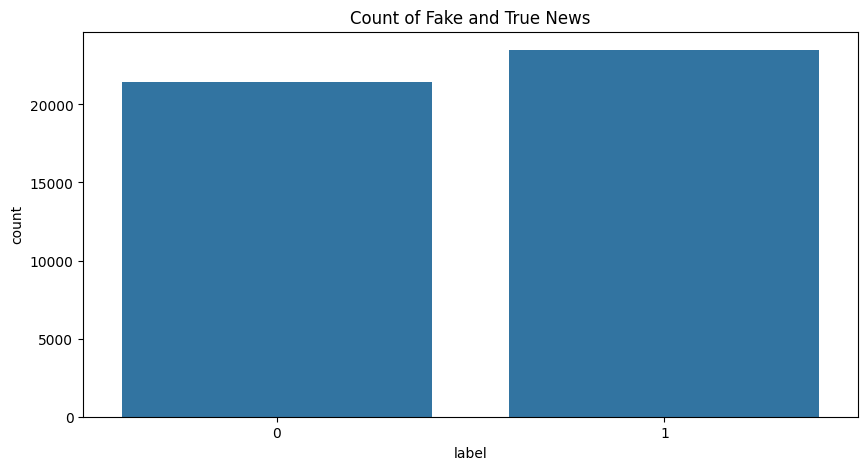

In [4]:
#creating a count plot for label column
fig = plt.figure(figsize=(10,5))
graph = sns.countplot(x="label", data=df)
plt.title("Count of Fake and True News")

Text(0.5, 1.0, 'Count of Subject')

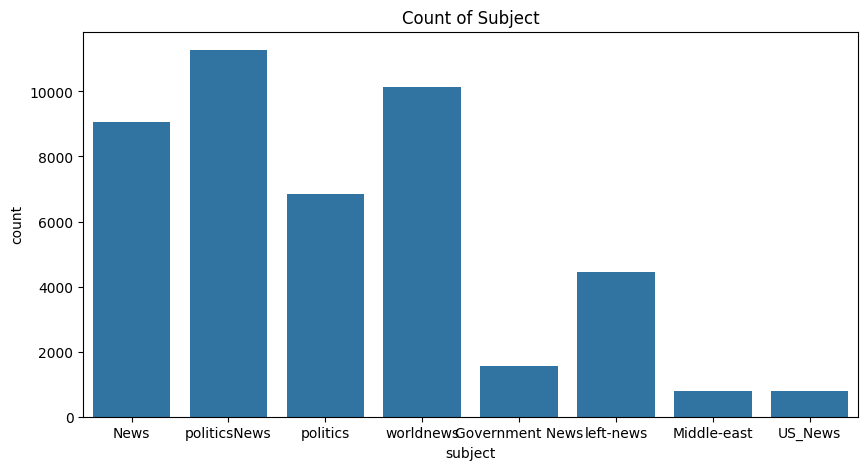

In [5]:
#creating a count plot for subject column
fig = plt.figure(figsize=(10,5))
graph = sns.countplot(x="subject", data=df)
plt.title("Count of Subject")

**Data Cleaning**

In [6]:
#checking the missing values in each columns
df.isna().sum()*100/len(df)

title      0.0
text       0.0
subject    0.0
date       0.0
label      0.0
content    0.0
dtype: float64

In [7]:
#Train test split 20%
df = df[['content', 'label']]

# Train-Test Split (Data Preparation)
X = df['content']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Total data: {len(df)}")
print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Total data: 44898
Train samples: 35918
Test samples: 8980


**Preprocessing & Feature Engineering**

This step converts raw text into numerical features using the essential NLP technique for this approach: TF-IDF.

In [ ]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Abhij\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [8]:
# --- 2.1 Text Cleaning Function ---
STOPWORDS = set(stopwords.words('english'))
# Lemmatizer is a slightly better version of stemming for reducing words to root form
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', '', text)
    # remove days text
    text = re.sub(r'\b(monday|tuesday|wednesday|thursday|friday|saturday|sunday)\b', '', text)
    # Tokenize and remove stopwords, then lemmatize
    text = ' '.join([lemmatizer.lemmatize(word) for word in text.split() if word not in STOPWORDS])
    return text

# Apply cleaning to the dataset
X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

# --- 2.2 TF-IDF Vectorization ---
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer:
# - stop_words='english' (already done, but good redundancy)
# - max_df=0.7: Ignore terms that appear in more than 70% of the documents (too common)
# - ngram_range=(1, 2): Consider single words (unigrams) and two-word phrases (bigrams)
# - max_features: Limit the vocabulary size to control model complexity and memory
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7, ngram_range=(1, 2), max_features=10000)

# Fit and transform the training data
tfidf_train = tfidf_vectorizer.fit_transform(X_train_clean)

# Only transform the test data (do not re-fit!)
tfidf_test = tfidf_vectorizer.transform(X_test_clean)

print(f"\nTF-IDF Matrix Shape (Train): {tfidf_train.shape}")
print(f"Feature count (vocabulary size): {len(tfidf_vectorizer.get_feature_names_out())}")
#


TF-IDF Matrix Shape (Train): (35918, 10000)
Feature count (vocabulary size): 10000


**Model Training and Evaluation**

We will use Logistic Regression as the primary classifier because it is simple, effective, and highly interpretable (a key requirement for XAI).


--- Training Logistic Regression Model ---

--- Logistic Regression Performance on Test Set ---
              precision    recall  f1-score   support

    Real (0)       0.99      0.99      0.99      4284
    Fake (1)       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

Area Under ROC Curve (AUC): 0.9991


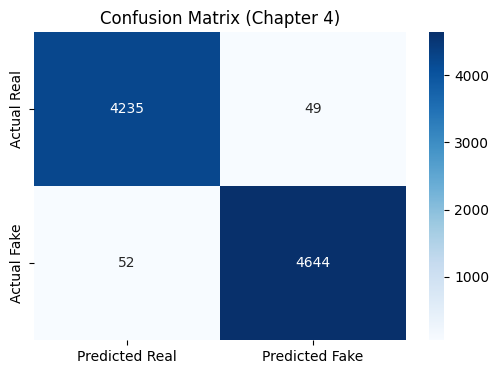

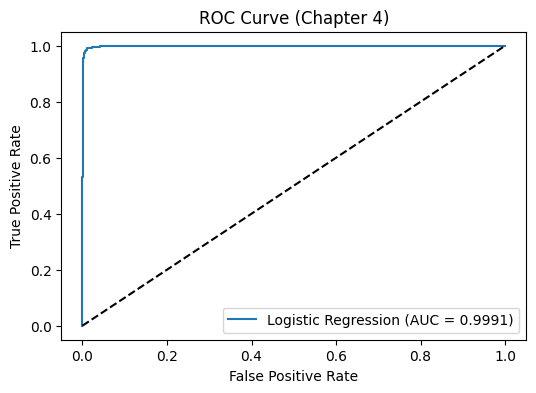

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# --- 3.1 Model Training ---
print("\n--- Training Logistic Regression Model ---")
lr_model = LogisticRegression(solver='liblinear', random_state=42)
lr_model.fit(tfidf_train, y_train)

# --- 3.2 Prediction and Metrics ---
y_pred = lr_model.predict(tfidf_test)
y_prob = lr_model.predict_proba(tfidf_test)[:, 1]

# --- 3.3 Classification Report (Empirical Results) ---
print("\n--- Logistic Regression Performance on Test Set ---")
print(classification_report(y_test, y_pred, target_names=['Real (0)', 'Fake (1)']))

# Calculate AUC (Crucial high-scoring metric)
auc = roc_auc_score(y_test, y_prob)
print(f"Area Under ROC Curve (AUC): {auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Real', 'Predicted Fake'],
            yticklabels=['Actual Real', 'Actual Fake'])
plt.title('Confusion Matrix (Chapter 4)')
plt.show()

# ROC Curve Visualization
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Chapter 4)')
plt.legend()
plt.show()

**Explainable AI (XAI) - Feature Importance**

For linear models like Logistic Regression, the model coefficients are the explanation. We can directly interpret which words contribute most strongly to the classification.


--- Top 10 Features Indicating 'FAKE' News (XAI) ---
              Feature  Coefficient  Absolute_Coefficient
4062            image     9.963213              9.963213
9547            video     9.955472              9.955472
3852          hillary     6.111386              6.111386
3553              gop     5.760189              5.760189
5830            obama     5.706691              5.706691
6564  president trump     5.554011              5.554011
311           america     4.631780              4.631780
313          american     4.498225              4.498225
4911             like     4.491641              4.491641
979          breaking     4.190904              4.190904

--- Top 10 Features Indicating 'REAL' News (XAI) ---
                 Feature  Coefficient  Absolute_Coefficient
7313             reuters   -25.853107             25.853107
9686  washington reuters   -10.259122             10.259122
6548    president donald    -5.832209              5.832209
9682          washington 

C:\Users\Abhij\AppData\Local\Temp\ipykernel_15704\3559871700.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_all_features, palette=['red' if c > 0 else 'blue' for c in top_all_features['Coefficient']])


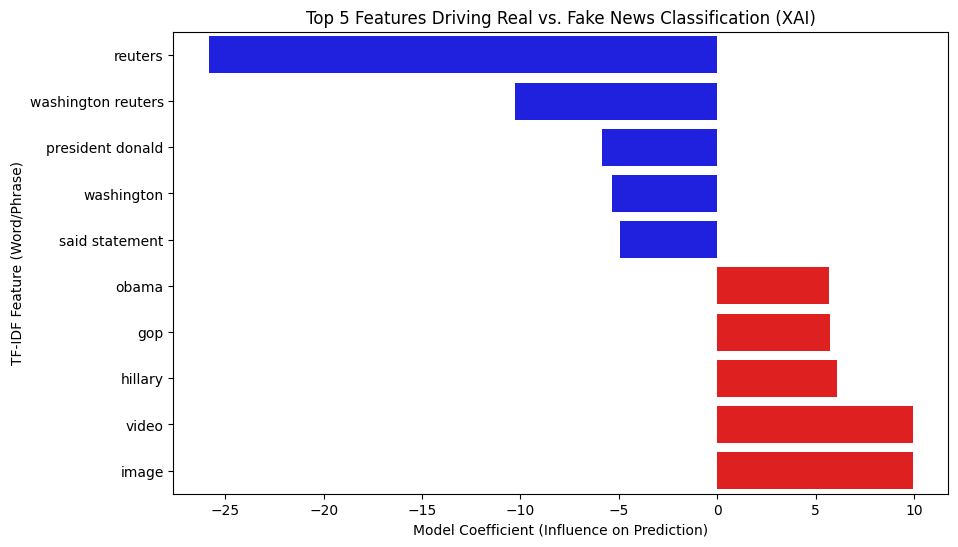


Interpretation for Report:
The model reveals that words like 'image' are strongly associated with fake news, while terms such as 'reuters' are indicative of legitimate reporting.


In [12]:
# --- 4.1 Extracting Coefficients for Interpretation ---
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = lr_model.coef_[0]

# Create a DataFrame for easy analysis
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort by coefficient magnitude
coef_df['Absolute_Coefficient'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Absolute_Coefficient', ascending=False)

# --- 4.2 Top 10 Features Indicating 'FAKE' News (Positive Coefficients) ---
# High positive coefficient means the word presence strongly pushes the prediction towards y=1 (Fake)
top_fake_features = coef_df[coef_df['Coefficient'] > 0].head(10)

print("\n--- Top 10 Features Indicating 'FAKE' News (XAI) ---")
print(top_fake_features)

# --- 4.3 Top 10 Features Indicating 'REAL' News (Negative Coefficients) ---
# High negative coefficient means the word presence strongly pushes the prediction towards y=0 (Real)
top_real_features = coef_df[coef_df['Coefficient'] < 0].head(10)

print("\n--- Top 10 Features Indicating 'REAL' News (XAI) ---")
print(top_real_features)

# --- 4.4 Visualization of Top Features ---
top_all_features = pd.concat([top_fake_features.head(5), top_real_features.head(5)])
top_all_features = top_all_features.sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=top_all_features, palette=['red' if c > 0 else 'blue' for c in top_all_features['Coefficient']])
plt.title('Top 5 Features Driving Real vs. Fake News Classification (XAI)')
plt.xlabel('Model Coefficient (Influence on Prediction)')
plt.ylabel('TF-IDF Feature (Word/Phrase)')
plt.show()
#

# --- 4.5 Interpretation for Chapter 5 (Findings) ---
print("\nInterpretation for Report:")
print(f"The model reveals that words like '{top_fake_features.iloc[0]['Feature']}' are strongly associated with fake news, while terms such as '{top_real_features.iloc[0]['Feature']}' are indicative of legitimate reporting.")

**Serialize the Model and Preprocessor**

In [13]:
import joblib
# Assume tfidf_vectorizer and lr_model are fitted from your notebook

# Save the fitted TF-IDF Vectorizer
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl') 

# Save the trained Logistic Regression model
joblib.dump(lr_model, 'lr_model.pkl')

['lr_model.pkl']